In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Flipkart Reviews Sentiment Analysis.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30000, 25)


,Review_ID,Product_ID,Product_Name,Category,Brand,Product_Price,Discount_Percentage,Selling_Price,Rating,Review_Summary,...,Verified_Purchase,Helpful_Votes,Not_Helpful_Votes,Payment_Method,Purchase_Channel,Delivery_Partner,Delivery_Days,Customer_Device,Review_Confidence,Customer_Experience_Score
0,FKR000001,PROD3286,HP 15s,Laptops,Wakefit,77090.0,15.7,64987.0,5,Loved it,...,Yes,3,2,Cash on Delivery,Website,Ekart,4,Android,0.712,1
1,FKR000002,PROD4257,LG 55 Smart TV,Televisions,Wakefit,47705.0,7.9,43936.0,5,Worth it,...,No,3,2,Credit Card,Website,Xpressbees,5,Windows,0.708,1
2,FKR000003,PROD6514,Sony WH-CH520,Audio,Realme,9835.0,12.0,8655.0,5,Great product,...,No,2,0,UPI,Website,Blue Dart,3,Windows,0.738,1
3,FKR000004,PROD5803,Deep Learning Book,Books,Prestige,1052.0,20.2,839.0,3,Average,...,No,1,0,Cash on Delivery,Mobile App,Ekart,6,Android,0.782,2
4,FKR000005,PROD5554,LG Washing Machine,Appliances,Sony,16314.0,6.7,15221.0,5,Very good,...,No,3,0,Credit Card,Website,Blue Dart,4,iOS,0.890,3


In [2]:
#SECTION 1:Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
#SECTION 2:Load the dataset
df = pd.read_csv("/content/Flipkart Reviews Sentiment Analysis.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Rows: 30000
Columns: 25


,Review_ID,Product_ID,Product_Name,Category,Brand,Product_Price,Discount_Percentage,Selling_Price,Rating,Review_Summary,...,Verified_Purchase,Helpful_Votes,Not_Helpful_Votes,Payment_Method,Purchase_Channel,Delivery_Partner,Delivery_Days,Customer_Device,Review_Confidence,Customer_Experience_Score
0,FKR000001,PROD3286,HP 15s,Laptops,Wakefit,77090.0,15.7,64987.0,5,Loved it,...,Yes,3,2,Cash on Delivery,Website,Ekart,4,Android,0.712,1
1,FKR000002,PROD4257,LG 55 Smart TV,Televisions,Wakefit,47705.0,7.9,43936.0,5,Worth it,...,No,3,2,Credit Card,Website,Xpressbees,5,Windows,0.708,1
2,FKR000003,PROD6514,Sony WH-CH520,Audio,Realme,9835.0,12.0,8655.0,5,Great product,...,No,2,0,UPI,Website,Blue Dart,3,Windows,0.738,1
3,FKR000004,PROD5803,Deep Learning Book,Books,Prestige,1052.0,20.2,839.0,3,Average,...,No,1,0,Cash on Delivery,Mobile App,Ekart,6,Android,0.782,2
4,FKR000005,PROD5554,LG Washing Machine,Appliances,Sony,16314.0,6.7,15221.0,5,Very good,...,No,3,0,Credit Card,Website,Blue Dart,4,iOS,0.890,3


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Review_ID                  30000 non-null  object 
 1   Product_ID                 30000 non-null  object 
 2   Product_Name               30000 non-null  object 
 3   Category                   30000 non-null  object 
 4   Brand                      30000 non-null  object 
 5   Product_Price              30000 non-null  float64
 6   Discount_Percentage        30000 non-null  float64
 7   Selling_Price              30000 non-null  float64
 8   Rating                     30000 non-null  int64  
 9   Review_Summary             29760 non-null  object 
 10  Review_Text                30000 non-null  object 
 11  Sentiment                  30000 non-null  object 
 12  Sentiment_Score            30000 non-null  float64
 13  Customer_City              29700 non-null  obj

,0
Review_ID,0
Product_ID,0
Product_Name,0
Category,0
Brand,0
Product_Price,0
Discount_Percentage,0
Selling_Price,0
Rating,0
Review_Summary,240


In [6]:
#SECTION 3:Understand the target
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,18671
Neutral,6019
Negative,5310


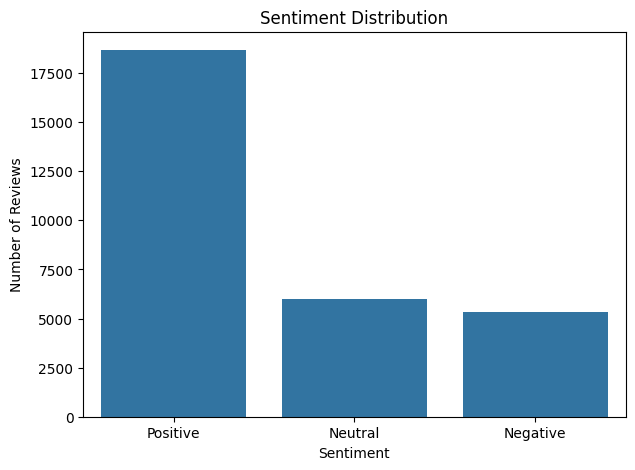

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [8]:
#SECTION 4:Create the actual NLP input
df["Combined_Review"] = (
    df["Review_Summary"].fillna("") + " " +
    df["Review_Text"].fillna("")
)

df[["Review_Summary", "Review_Text", "Combined_Review", "Sentiment"]].head()

,Review_Summary,Review_Text,Combined_Review,Sentiment
0,Loved it,"good product, works perfectly, keyboard feels ...","Loved it good product, works perfectly, keyboa...",Positive
1,Worth it,"perfect purchase, loved it, picture quality is...","Worth it perfect purchase, loved it, picture q...",Positive
2,Great product,"good product, works perfectly, bass is good.","Great product good product, works perfectly, b...",Positive
3,Average,"quality is neither very good nor very bad, con...",Average quality is neither very good nor very ...,Neutral
4,Very good,"quality is superb and performance is great, bu...",Very good quality is superb and performance is...,Positive


In [9]:
#SECTION 5:Clean the text
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [10]:
df["Cleaned_Review"] = df["Combined_Review"].apply(clean_text)

df[["Combined_Review", "Cleaned_Review"]].head()

,Combined_Review,Cleaned_Review
0,"Loved it good product, works perfectly, keyboa...",loved it good product works perfectly keyboard...
1,"Worth it perfect purchase, loved it, picture q...",worth it perfect purchase loved it picture qua...
2,"Great product good product, works perfectly, b...",great product good product works perfectly bas...
3,Average quality is neither very good nor very ...,average quality is neither very good nor very ...
4,Very good quality is superb and performance is...,very good quality is superb and performance is...


In [11]:
#SECTION 6:Remove stopwords
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

df["Processed_Review"] = df["Cleaned_Review"].apply(remove_stopwords)

In [12]:
df[["Cleaned_Review", "Processed_Review"]].head()

,Cleaned_Review,Processed_Review
0,loved it good product works perfectly keyboard...,loved good product works perfectly keyboard fe...
1,worth it perfect purchase loved it picture qua...,worth perfect purchase loved picture quality s...
2,great product good product works perfectly bas...,great product good product works perfectly bas...
3,average quality is neither very good nor very ...,average quality neither good bad content useful
4,very good quality is superb and performance is...,good quality superb performance great build qu...


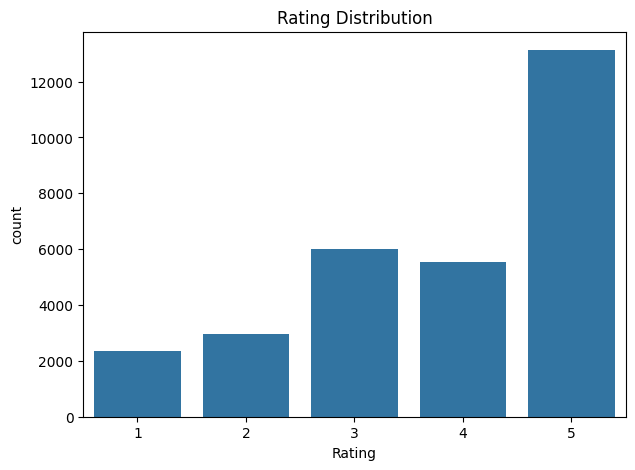

In [13]:
#SECTION 7:EDA
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Rating Distribution")
plt.show()

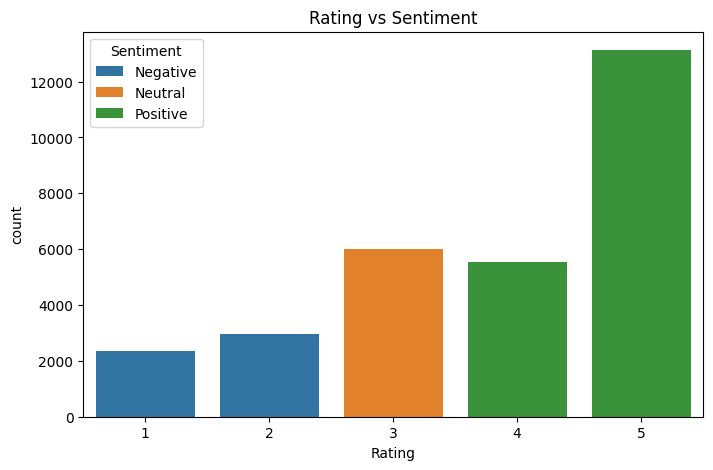

In [14]:
#Rating vs sentiment
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Rating",
    hue="Sentiment"
)

plt.title("Rating vs Sentiment")
plt.show()

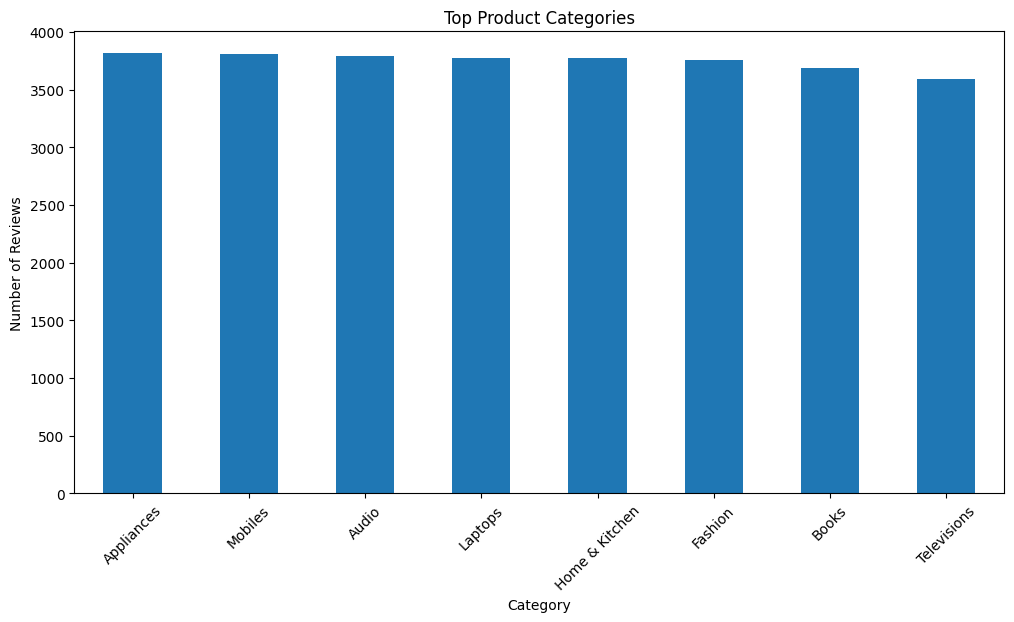

In [15]:
#Category
plt.figure(figsize=(12,6))

df["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [16]:
#SECTION 8:Train/test split
X = df["Processed_Review"]
y = df["Sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
#SECTION 9:TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [19]:
#SECTION 10:Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(
    "Macro F1:",
    f1_score(y_test, nb_pred, average="macro")
)

print(
    classification_report(
        y_test,
        nb_pred
    )
)

Naive Bayes
Accuracy: 0.9998333333333334
Macro F1: 0.9997983605696869
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [20]:
#SECTION 11:Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(X_test_tfidf)
print("Logistic Regression")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        lr_pred,
        average="macro"
    )
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression
Accuracy: 1.0
Macro F1: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [21]:
#SECTION 12:Linear SVM
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(X_test_tfidf)
print("Linear SVM")

print(
    "Accuracy:",
    accuracy_score(y_test, svm_pred)
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(
    classification_report(
        y_test,
        svm_pred
    )
)

Linear SVM
Accuracy: 1.0
Macro F1: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [22]:
#SECTION 13:Make a comparison table
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "Precision": [
        precision_score(y_test, nb_pred, average="macro"),
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, svm_pred, average="macro")
    ],

    "Recall": [
        recall_score(y_test, nb_pred, average="macro"),
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, svm_pred, average="macro")
    ],

    "Macro F1": [
        f1_score(y_test, nb_pred, average="macro"),
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, svm_pred, average="macro")
    ]
})

results

,Model,Accuracy,Precision,Recall,Macro F1
0,Naive Bayes,0.999833,0.999911,0.999686,0.999798
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000
2,Linear SVM,1.000000,1.000000,1.000000,1.000000


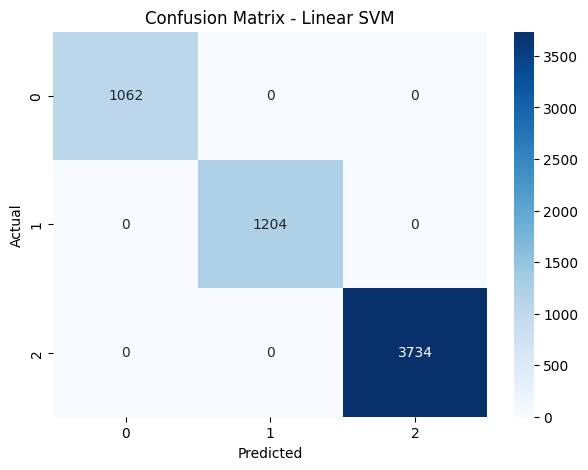

In [23]:
#SECTION 14:Confusion matrix
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [24]:
#SECTION 15:Which words influence sentiment?
feature_names = np.array(
    tfidf.get_feature_names_out()
)

for i, class_name in enumerate(svm_model.classes_):

    coef = svm_model.coef_[i]

    top_positive = feature_names[
        np.argsort(coef)[-15:]
    ]

    print(
        class_name,
        ":",
        top_positive
    )

Negative : ['poor experience' 'experience product' 'received defective' 'waste'
 'waste money' 'expected much' 'much' 'much better' 'bad' 'good worth'
 'disappointed purchase' 'defective' 'disappointed' 'worth price' 'poor']
Neutral : ['quality price' 'product price' 'usable' 'received product'
 'product usable' 'could better' 'neither good' 'neither'
 'quality neither' 'decent' 'fair' 'performance acceptable' 'acceptable'
 'okay' 'average']
Positive : ['happy purchase' 'really happy' 'superb' 'product good' 'loved'
 'excellent product' 'product totally' 'totally' 'amazing product'
 'totally worth' 'amazing' 'better expected' 'satisfied'
 'expected satisfied' 'excellent']


In [26]:
#LSTM implementation
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
#tokenize:
tokenizer = Tokenizer(
    num_words=20000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
#Padding:
max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post"
)

In [27]:
#Convert sentiment into numbers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [29]:
#Build LSTM
model = Sequential([

    Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=100
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])
#compile:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#train:
history = model.fit(
    X_train_pad,
    y_train_encoded,

    validation_split=0.2,

    epochs=5,
    batch_size=64
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.6207 - loss: 0.9322 - val_accuracy: 0.6281 - val_loss: 0.9192
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6209 - loss: 0.9303 - val_accuracy: 0.6281 - val_loss: 0.9205
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6209 - loss: 0.9281 - val_accuracy: 0.6281 - val_loss: 0.9172
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6209 - loss: 0.9279 - val_accuracy: 0.6281 - val_loss: 0.9170
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6209 - loss: 0.9281 - val_accuracy: 0.6281 - val_loss: 0.9169


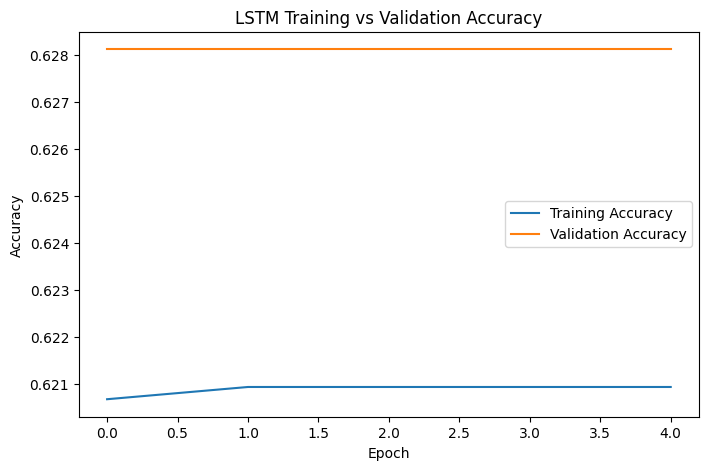

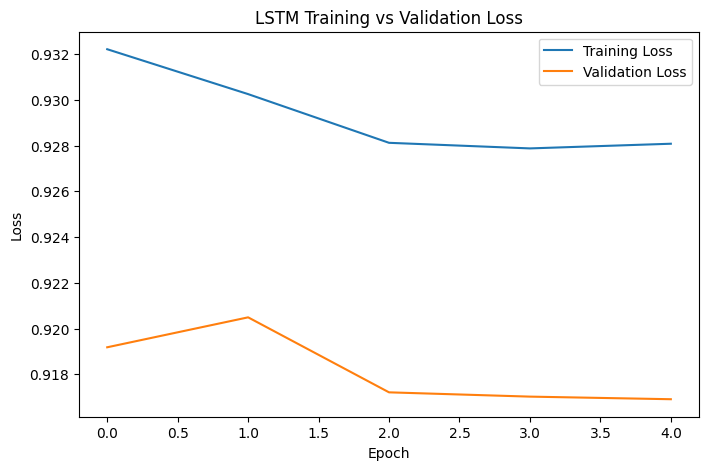

In [30]:
#Plot training performance
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training vs Validation Accuracy")
plt.legend()

plt.show()

#loss

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()

plt.show()

In [32]:
#Demo
def predict_sentiment(review):

    cleaned = clean_text(review)
    cleaned = remove_stopwords(cleaned)

    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )

    padded = pad_sequences(
        sequence,
        maxlen=100,
        padding="post"
    )

    prediction = model.predict(
        padded,
        verbose=0
    )[0]

    index = np.argmax(prediction)

    sentiment = label_encoder.inverse_transform(
        [index]
    )[0]

    confidence = prediction[index] * 100

    return sentiment, confidence

In [33]:
review = input("Enter a Flipkart review: ")

sentiment, confidence = predict_sentiment(review)

print("\nPredicted Sentiment:", sentiment)
print(f"Confidence: {confidence:.2f}%")

Enter a Flipkart review: The product is amazing and delivery was very fast

Predicted Sentiment: Positive
Confidence: 63.12%
